# Competitor Comparison

The purpose of this notebook is to compare the Robust Mixed Effects (RoME) algorithm to various competing algorithms.
This notebook contains three separate simulations that compare these methods.

In the first simulation, the standard Thompson sampling assumptions hold,
and the users are assumed to be homogeneous in the sense that their advantage functions (causal effects) are the same.

The second situation is similar, but users are heterogeneous in the sense that they have different advantage functions.

In the third simulation, the data-generating mechanism is much more complex.
In addition to being nonlinear, it also includes effects for users and time.
Consequently, only the RoME method performs well in this setting.

# Shared Setup

In [1]:
# Generic imports
import pandas as pd
import numpy as np
import scipy
import scipy.sparse
from scipy.stats import ttest_1samp
import matplotlib.pyplot as plt
import seaborn as sns
from river import linear_model
import copy
from multiprocessing import cpu_count
from joblib import Parallel, delayed
import pickle
import tensorflow as tf
import keras
from keras import layers, regularizers
import time

pd.set_option('display.max_rows', 1000)
pd.set_option('display.max_columns', 50)

Matplotlib created a temporary config/cache directory at /tmp/matplotlib-inbcmgws because the default path (/home/jovyan/.cache/matplotlib) is not a writable directory; it is highly recommended to set the MPLCONFIGDIR environment variable to a writable directory, in particular to speed up the import of Matplotlib and to better support multiprocessing.
2025-01-11 22:34:47.539007: I tensorflow/core/platform/cpu_feature_guard.cc:193] This TensorFlow binary is optimized with oneAPI Deep Neural Network Library (oneDNN) to use the following CPU instructions in performance-critical operations:  SSE4.1 SSE4.2 AVX AVX2 AVX512F FMA
To enable them in other operations, rebuild TensorFlow with the appropriate compiler flags.


In [2]:
# Imports from this project
from models.models import OracleTS, StandardTS, ActionCenteredTS, RoME, IntelligentPooling, UserLaplacian
from models.river_wrapper import RiverBatchEstimator
from models.bagging_mod import BaggingRegressor
from models.utils import find_neighbors
from simulations.data_generator import DataGenerator

In [3]:
plt.rcParams['axes.prop_cycle'] = plt.cycler(color=plt.cm.tab10.colors)
plt.rcParams['font.family'] = 'sans-serif'

In [4]:
# Simulation setup: try some different values
N_STAGES = 200
N_OBSERVATIONS = N_STAGES * (N_STAGES + 1) // 2
N = N_STAGES
T = N_STAGES
THETA = np.array([1., 0.5, -4.])
CONTEXT_DIM = 2
EXTRA_CONTEXT_DIM = 2
LINEAR_BASELINE_COEF = np.array([2., -2., 3.])
THETA_TIME_INIT = np.array([-2., -4., 6.])
P = THETA.size
n_jobs = 25
REPS = 50
N_NEIGHBORS = 5

In [5]:
def get_max_norm(x):
    squared_norms = (x**2).sum(axis=1)
    norms = np.sqrt(squared_norms)
    max_norm = np.max(norms)
    return max_norm

def get_max_norm_for_pairs(x, pairs):
    x_diffs = x[pairs[0]] - x[pairs[1]]
    max_norm = get_max_norm(x_diffs)
    return max_norm

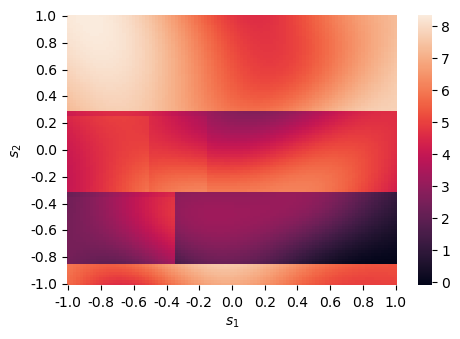

In [6]:
homogeneous_data_generator = DataGenerator(stage_max=N_STAGES, assumptions="homogeneous", linear_baseline_coef=LINEAR_BASELINE_COEF, random_seed=1)
homogeneous_data_generator = homogeneous_data_generator.sample_theta(theta_base=THETA)

heterogeneous_data_generator = DataGenerator(stage_max=N_STAGES, assumptions="heterogeneous", linear_baseline_coef=LINEAR_BASELINE_COEF, random_seed=1)
heterogeneous_data_generator = heterogeneous_data_generator.sample_theta(theta_base=THETA)

nonlinear_data_generator = DataGenerator(stage_max=N_STAGES, assumptions="nonlinear", random_seed=3, nonlinear_scale=1.)  # Seed chosen for its interesting nonlinear relationships
nonlinear_data_generator = nonlinear_data_generator.sample_theta(theta_base=THETA, theta_time_init=THETA_TIME_INIT)

# Baseline Reward
num_vals = 101
s1_vals = np.round(np.linspace(-1., 1., num=num_vals), 2)
s2_vals = np.round(np.linspace(-1., 1., num=num_vals), 2)
s1_vals_repped, s2_vals_repped = np.meshgrid(s1_vals, s2_vals)
context_values = np.vstack([s1_vals_repped.flatten(), s2_vals_repped.flatten()]).T
baseline_vals = nonlinear_data_generator._nonlinear_baseline_function(context_values, scale=nonlinear_data_generator.nonlinear_scale)
heatmap_min = np.min(baseline_vals)
heatmap_max = np.max(baseline_vals)

baseline_vals_df = pd.DataFrame(
    data=baseline_vals.reshape((num_vals, num_vals)),
    index=s1_vals,
    columns=s2_vals).sort_index(ascending=False)

fig, ax = plt.subplots(figsize=(5, 3.5))
ax = sns.heatmap(baseline_vals_df, xticklabels=10, yticklabels=10, ax=ax)
plt.xlabel("$s_{1}$")
plt.ylabel("$s_{2}$")
# plt.title("Baseline Reward as a Function of State")
fig.tight_layout()
fig.savefig("figures/baseline_reward.png")
fig.savefig("figures/baseline_reward.pdf")
plt.show()

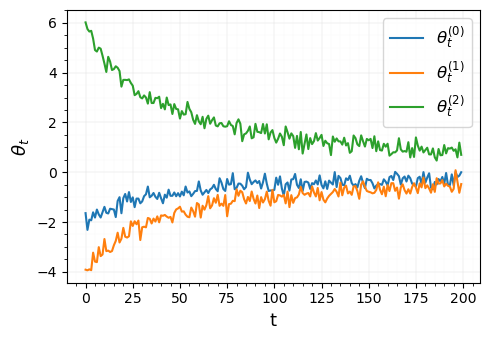

In [7]:
# Time-specifc thetas
fig, ax = plt.subplots(figsize=(5, 3.5))
for i in range(THETA.size):
    label = "$\\theta^{(idx)}_{t}$".replace("idx", str(i))
    ax.plot(nonlinear_data_generator.theta_time[:, i], alpha=1, label=label)
ax.grid(which='major', color='#DDDDDD', linewidth=0.3)
ax.grid(which='minor', color='#EEEEEE', linestyle=':', linewidth=0.3)
ax.minorticks_on()
ax.set_xlabel("t", fontsize=13)
ax.set_ylabel("$\\theta_{t}$", fontsize=13)
# plt.title("Values of $\\theta_{time}$ Plotted Over Time")
ax.legend(fontsize=12)
fig.tight_layout()
fig.savefig("figures/theta_time.png")
fig.savefig("figures/theta_time.pdf")
plt.show()

2025-01-11 22:34:53.401354: I tensorflow/core/platform/cpu_feature_guard.cc:193] This TensorFlow binary is optimized with oneAPI Deep Neural Network Library (oneDNN) to use the following CPU instructions in performance-critical operations:  SSE4.1 SSE4.2 AVX AVX2 AVX512F FMA
To enable them in other operations, rebuild TensorFlow with the appropriate compiler flags.


Epoch 1/20
200/200 [==============================] - 1s 2ms/step - loss: 1.8461 - val_loss: 1.0910
Epoch 2/20
200/200 [==============================] - 0s 1ms/step - loss: 1.0696 - val_loss: 1.0696
Epoch 3/20
200/200 [==============================] - 0s 1ms/step - loss: 1.0578 - val_loss: 1.0522
Epoch 4/20
200/200 [==============================] - 0s 1ms/step - loss: 1.0494 - val_loss: 1.0616
Epoch 5/20
200/200 [==============================] - 0s 1ms/step - loss: 1.0481 - val_loss: 1.0676
Epoch 6/20
200/200 [==============================] - 0s 1ms/step - loss: 1.0428 - val_loss: 1.0571
Epoch 7/20
200/200 [==============================] - 0s 1ms/step - loss: 1.0393 - val_loss: 1.0493
Epoch 8/20
200/200 [==============================] - 0s 1ms/step - loss: 1.0320 - val_loss: 1.0381
Epoch 9/20
200/200 [==============================] - 0s 1ms/step - loss: 1.0326 - val_loss: 1.0344
Epoch 10/20
200/200 [==============================] - 0s 1ms/step - loss: 1.0361 - val_loss: 1.0355

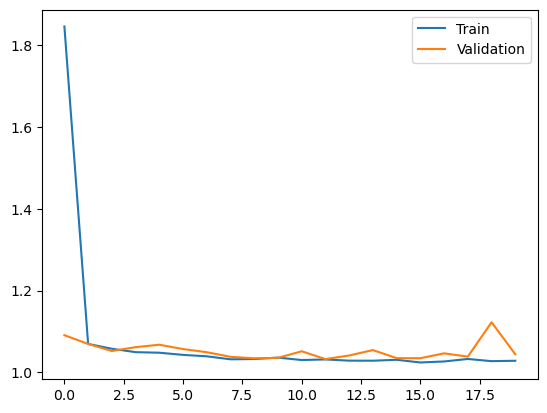

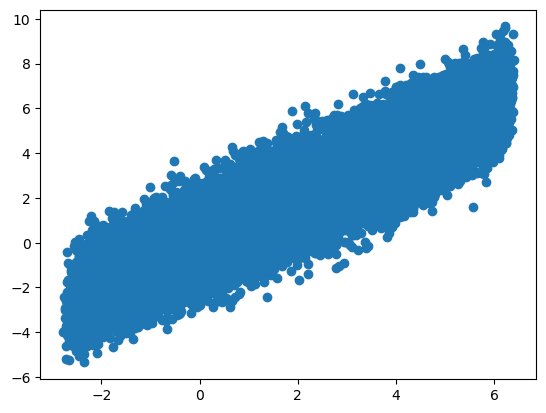

INFO:tensorflow:Assets written to: tri-homogeneous-nn/assets


INFO:tensorflow:Assets written to: tri-homogeneous-nn/assets


Epoch 1/20
200/200 [==============================] - 1s 2ms/step - loss: 1.4359 - val_loss: 1.1077
Epoch 2/20
200/200 [==============================] - 0s 1ms/step - loss: 1.0837 - val_loss: 1.0873
Epoch 3/20
200/200 [==============================] - 0s 1ms/step - loss: 1.0712 - val_loss: 1.0904
Epoch 4/20
200/200 [==============================] - 0s 1ms/step - loss: 1.0724 - val_loss: 1.0869
Epoch 5/20
200/200 [==============================] - 0s 1ms/step - loss: 1.0583 - val_loss: 1.0712
Epoch 6/20
200/200 [==============================] - 0s 1ms/step - loss: 1.0472 - val_loss: 1.0600
Epoch 7/20
200/200 [==============================] - 0s 1ms/step - loss: 1.0448 - val_loss: 1.0567
Epoch 8/20
200/200 [==============================] - 0s 1ms/step - loss: 1.0402 - val_loss: 1.0598
Epoch 9/20
200/200 [==============================] - 0s 1ms/step - loss: 1.0486 - val_loss: 1.0567
Epoch 10/20
200/200 [==============================] - 0s 1ms/step - loss: 1.0395 - val_loss: 1.0597

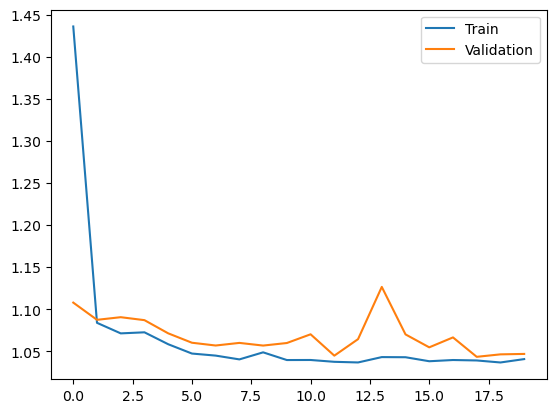

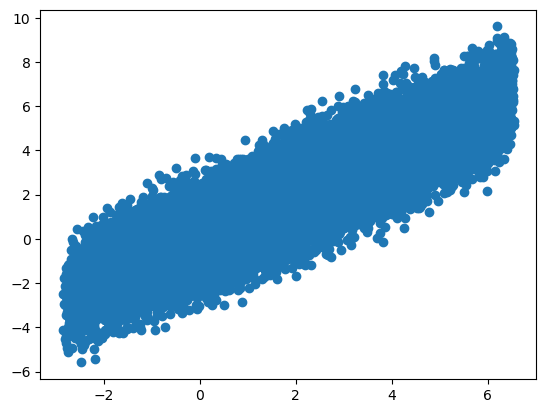

INFO:tensorflow:Assets written to: tri-heterogeneous-nn/assets


INFO:tensorflow:Assets written to: tri-heterogeneous-nn/assets


Epoch 1/50
200/200 [==============================] - 1s 2ms/step - loss: 5.6615 - val_loss: 4.6824
Epoch 2/50
200/200 [==============================] - 0s 1ms/step - loss: 3.2713 - val_loss: 2.3954
Epoch 3/50
200/200 [==============================] - 0s 1ms/step - loss: 2.0594 - val_loss: 1.8196
Epoch 4/50
200/200 [==============================] - 0s 1ms/step - loss: 1.7254 - val_loss: 1.5579
Epoch 5/50
200/200 [==============================] - 0s 1ms/step - loss: 1.5522 - val_loss: 1.4539
Epoch 6/50
200/200 [==============================] - 0s 1ms/step - loss: 1.5126 - val_loss: 1.5575
Epoch 7/50
200/200 [==============================] - 0s 1ms/step - loss: 1.4723 - val_loss: 1.5292
Epoch 8/50
200/200 [==============================] - 0s 1ms/step - loss: 1.4407 - val_loss: 1.4545
Epoch 9/50
200/200 [==============================] - 0s 1ms/step - loss: 1.4536 - val_loss: 1.4487
Epoch 10/50
200/200 [==============================] - 0s 1ms/step - loss: 1.4325 - val_loss: 1.4009

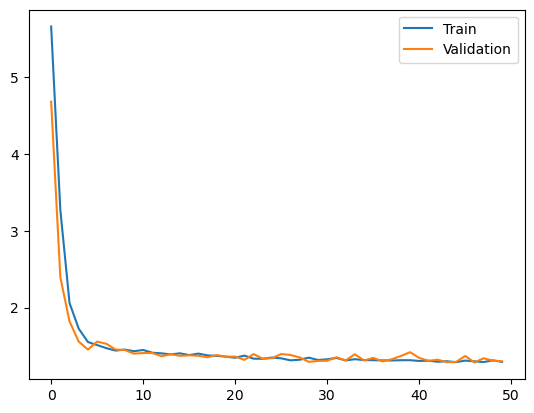

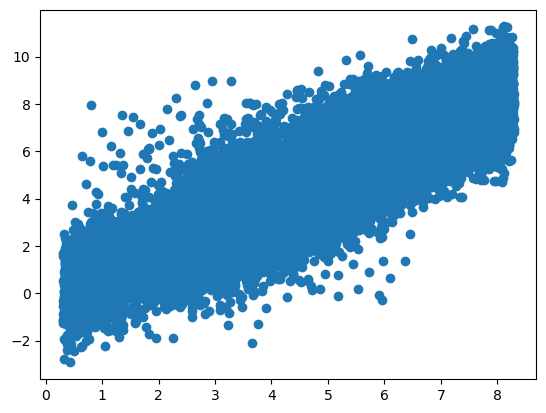

INFO:tensorflow:Assets written to: tri-nonlinear-nn/assets


INFO:tensorflow:Assets written to: tri-nonlinear-nn/assets


In [8]:
# Neural network stuff
nn_input_dim = CONTEXT_DIM + EXTRA_CONTEXT_DIM

data_generators = [homogeneous_data_generator, heterogeneous_data_generator, nonlinear_data_generator]
model_files = ["tri-homogeneous-nn", "tri-heterogeneous-nn", "tri-nonlinear-nn"]
for i, (data_generator, model_file) in enumerate(zip(data_generators, model_files)):
    # Create data
    data_generator = data_generator.generate_all_contexts(context_dim=CONTEXT_DIM, extra_context_dim=EXTRA_CONTEXT_DIM)
    X_train, y_train = data_generator.generate_baselines_for_nn()
    
    data_generator = data_generator.reset()
    data_generator = data_generator.generate_all_contexts(context_dim=CONTEXT_DIM, extra_context_dim=EXTRA_CONTEXT_DIM)
    X_validation, y_validation = data_generator.generate_baselines_for_nn()
    
    # Train model
    penalty = 0.001
    nn_output_dim = 10
    model = keras.Sequential(
        [
            keras.Input(shape=(nn_input_dim,), name="input"),
            layers.Dense(10, activation="relu", name="layer1", kernel_regularizer=regularizers.l2(penalty)),
            layers.Dense(20, activation="relu", name="layer2", kernel_regularizer=regularizers.l2(penalty)),
            layers.Dense(20, activation="tanh", name="layer3", kernel_regularizer=regularizers.l2(penalty)),
            layers.Dense(nn_output_dim, activation="tanh", name="layer4", kernel_regularizer=regularizers.l2(penalty)),
            layers.Dense(1, name="output", kernel_regularizer=regularizers.l2(penalty)),
        ]
    )
    opt = keras.optimizers.Adam(learning_rate=0.01)
    model.compile(loss="mse", optimizer=opt)
    history = model.fit(
        X_train,
        y_train,
        batch_size=200,
        validation_data=(X_validation, y_validation),
        epochs=50 if i == 2 else 20,
        # epochs=1,
        verbose=1
    )
    
    plt.plot(history.history['loss'], label="Train")
    plt.plot(history.history['val_loss'], label="Validation")
    plt.legend()
    plt.show()

    preds_validation = model(X_validation)
    plt.scatter(preds_validation, y_validation)
    plt.show()
    
    # Featurizer model
    featurizer_nn_model = keras.Model(
        inputs=model.input,
        outputs=model.get_layer("layer4").output)
    featurizer_nn_model.compile()
    featurizer_nn_model.save(model_file)

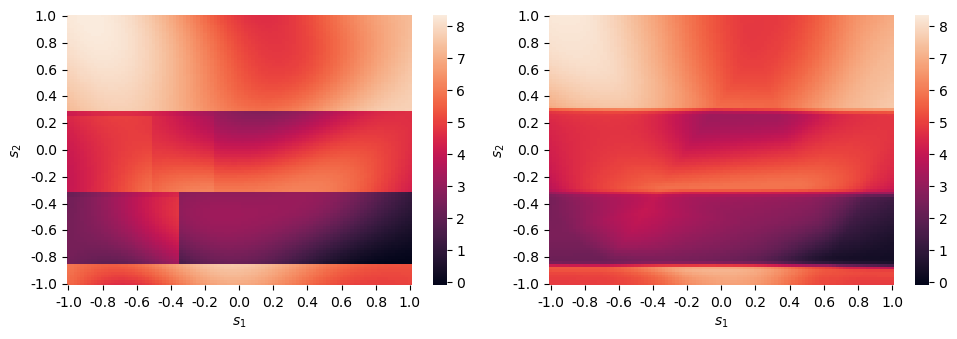

In [9]:
# Baseline Reward
num_vals = 101
s1_vals = np.round(np.linspace(-1., 1., num=num_vals), 2)
s2_vals = np.round(np.linspace(-1., 1., num=num_vals), 2)
s1_vals_repped, s2_vals_repped = np.meshgrid(s1_vals, s2_vals)
context_values = np.vstack([s1_vals_repped.flatten(), s2_vals_repped.flatten()]).T
baseline_vals = nonlinear_data_generator._nonlinear_baseline_function(context_values, scale=nonlinear_data_generator.nonlinear_scale)

baseline_vals_df = pd.DataFrame(
    data=baseline_vals.reshape((num_vals, num_vals)),
    index=s1_vals,
    columns=s2_vals).sort_index(ascending=False)

fig, ax = plt.subplots(1, 2, figsize=(10, 3.5))
sns.heatmap(baseline_vals_df, vmin=heatmap_min, vmax=heatmap_max, xticklabels=10, yticklabels=10, ax=ax[0])
ax[0].set_xlabel("$s_{1}$")
ax[0].set_ylabel("$s_{2}$")

nn_context_values = np.hstack([context_values, np.zeros_like(context_values)])
nn_baseline_vals = model(nn_context_values).numpy()
nn_baseline_vals_df = pd.DataFrame(
    data=nn_baseline_vals.reshape((num_vals, num_vals)),
    index=s1_vals,
    columns=s2_vals).sort_index(ascending=False)

sns.heatmap(nn_baseline_vals_df, vmin=heatmap_min, vmax=heatmap_max, xticklabels=10, yticklabels=10, ax=ax[1])
ax[1].set_xlabel("$s_{1}$")
ax[1].set_ylabel("$s_{2}$")

fig.tight_layout()
fig.savefig("figures/nn_baseline_reward_comparison.png")
fig.savefig("figures/nn_baseline_reward_comparison.pdf")
plt.show()

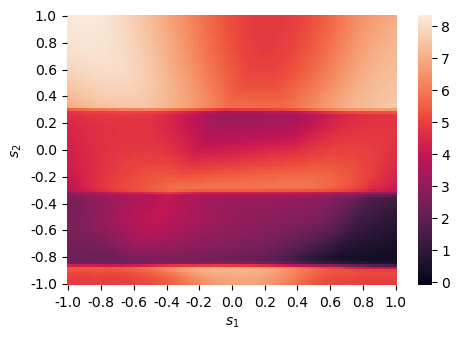

In [10]:
fig, ax = plt.subplots(figsize=(5, 3.5))
ax = sns.heatmap(nn_baseline_vals_df, vmin=heatmap_min, vmax=heatmap_max, xticklabels=10, yticklabels=10, ax=ax)
plt.xlabel("$s_{1}$")
plt.ylabel("$s_{2}$")
# plt.title("Baseline Reward as a Function of State")
fig.tight_layout()
fig.savefig("figures/nn_baseline_reward.png")
fig.savefig("figures/nn_baseline_reward.pdf")
plt.show()

In [11]:
# This determines the plotting order
non_oracle_method_names = [
    "IntelPooling",
    "RoME-BLM",
    "RoME",
    "RoME-SU",
    "AC",
    "Standard",
    "Neural-Linear",
    "NNR-Linear"
]

def create_reward_dict(data_generator, nn_model_name, seed):
    np.random.seed(seed)
    user_pairs, L_user = find_neighbors(
        data_generator.theta_user + 0.1*np.random.normal(size=data_generator.theta_user.shape),
        N_NEIGHBORS)
    time_pairs, L_time = find_neighbors(
        data_generator.theta_time + 1.*np.random.normal(size=data_generator.theta_user.shape),
        N_NEIGHBORS)
    
    bagged_lm = RiverBatchEstimator(
        BaggingRegressor(
            linear_model.LinearRegression(l2=1e-8, intercept_lr=0.1),
            n_models=10,
            subsample=0.8
        )
    )

    # Set covariances
    cov_epsilon = 1e-18
    user_cov = np.cov(data_generator.theta_user.T)
    if user_cov.sum() < cov_epsilon:
        user_cov += cov_epsilon * np.eye(user_cov.shape[0])
    time_cov = np.cov(data_generator.theta_time.T)
    if time_cov.sum() < cov_epsilon:
        time_cov += cov_epsilon * np.eye(time_cov.shape[0])

    nn = tf.keras.models.load_model(nn_model_name)
    nn_numpy = lambda x: nn(x).numpy()
    
    non_oracle_methods_dict = {
        "IntelPooling": IntelligentPooling(N, T, P, DataGenerator._featurize, user_cov=user_cov, time_cov=time_cov),
        "RoME": RoME(N, T, P, DataGenerator._featurize, L_user, L_time, user_cov=user_cov, time_cov=time_cov, n_neighbors=N_NEIGHBORS),
        "RoME-BLM": RoME(N, T, P, DataGenerator._featurize, L_user, L_time, user_cov=user_cov, time_cov=time_cov, ml_interactions=True, ml_model=bagged_lm, n_neighbors=N_NEIGHBORS),
        "RoME-SU": RoME(1, T, P, DataGenerator._featurize, L_user, L_time, user_cov=user_cov, time_cov=time_cov, n_neighbors=N_NEIGHBORS, pool_users=False),
        "AC": ActionCenteredTS(N, T, P, DataGenerator._featurize),
        "Standard": StandardTS(N, T, P, DataGenerator._featurize),
        "Neural-Linear": StandardTS(N, T, P, DataGenerator._featurize, nn=nn_numpy, nn_dim=nn_output_dim),
        "NNR-Linear": UserLaplacian(N, T, P, DataGenerator._featurize, L_user, user_cov=user_cov),
    }
    methods_dict = copy.copy(non_oracle_methods_dict)
    methods_dict["Oracle"] = OracleTS(N, T, THETA, data_generator.theta_user, data_generator.theta_time, DataGenerator._featurize)
    
    # Dictionary for storing rewards
    rewards_dict = {k:np.zeros((N, T)) for k in methods_dict}
    timings_dict = {}

    # Generate context vectors that we'll use for all models
    data_generator = data_generator.generate_all_contexts(context_dim=CONTEXT_DIM, extra_context_dim=EXTRA_CONTEXT_DIM)

    # Iterate through methods
    for method_name, method in methods_dict.items():
        rewards = []
        data_generator = data_generator.reset()
        method.reset()
        method_start_time = time.time()

        while not data_generator.finished:
            # Randomly samples action from current policy
            context, context_extra, user_idx, time_idx = data_generator.get_current_context()
            action = method.sample_action(context, user_idx, time_idx)

            # Plays action and returns reward
            reward = data_generator.play_action(action)
            rewards_dict[method_name][user_idx, time_idx] = reward

            # Update method inferences
            method.update(context, context_extra, user_idx, time_idx, action, reward)
        method_end_time = time.time()
        method_elapsed_time = method_end_time - method_start_time
        timings_dict[method_name] = method_elapsed_time

    return rewards_dict, timings_dict

In [12]:
def run_simulation(data_generator, nn_model_name, REPS=REPS, n_jobs=cpu_count()):    
    # Perform whole simulation REPS times
    pool_args = zip(
        [copy.deepcopy(data_generator) for _ in range(REPS)],
        [nn_model_name]*REPS,
        range(REPS))
    print("Starting parallel")
    list_of_tuples_of_dicts = Parallel(n_jobs=n_jobs)(delayed(create_reward_dict)(*arg) for arg in pool_args)    
    print("Parallel closed")
    rewards_list_of_dicts = [t[0] for t in list_of_tuples_of_dicts]
    timings_list_of_dicts = [t[1] for t in list_of_tuples_of_dicts]
    rewards_dict = {}
    timings_dict = {}
    method_names = list(rewards_list_of_dicts[0].keys())
    non_oracle_method_names = list(set(method_names) - set(["Oracle"]))
    for method_name in method_names:
        rewards_dict[method_name] = np.asarray([
            rewards_list_of_dicts[i][method_name]
            for i in range(REPS)])
        timings_dict[method_name] = np.asarray([
            timings_list_of_dicts[i][method_name]
            for i in range(REPS)])
                
    return rewards_dict, timings_dict

In [13]:
def get_avg_stage_reward(a):
    means = [a[:, ::-1].diagonal(i, axis1=1, axis2=2).mean(axis=1) for i in range(-a.shape[1]+1,a.shape[2])]
    return np.asarray(means)[:a.shape[1]]


def plot_rewards_dict(rewards_dict, assumptions):
    fig, ax = plt.subplots(1, 2, figsize=(8, 4))
    ax0 = ax[0]
    ax1 = ax[1]
    
    # Calculate incremental regret
    oracle_incremental_regret = get_avg_stage_reward(rewards_dict["Oracle"])
    incremental_regret_dict = {
        method_name: (oracle_incremental_regret - get_avg_stage_reward(rewards_dict[method_name])).mean(axis=1)  # Mean over reps
        for method_name in non_oracle_method_names}

    # Calculate cumulative regret
    cumulative_regret_dict = {method_name: np.cumsum(incremental_regret_dict[method_name]) for method_name in non_oracle_method_names}

    # Plot incremental regret
    for method_name in non_oracle_method_names:
        ax0.plot(incremental_regret_dict[method_name], label=method_name, )
    ax0.set_title("(a) Incremental Regret Over Time", pad=10)
    ax0.set_ylabel("Incremental Regret")
    ax0.set_xlabel("Stage")
    ax0.legend()

    # Plot cumulative regret
    for method_name in non_oracle_method_names:
        ax1.plot(cumulative_regret_dict[method_name], label=method_name)
    ax1.set_title("(b) Cumulative Regret Over Time", pad=10)
    ax1.set_ylabel("Cumulative Regret")
    ax1.set_xlabel("Stage")
    plt.legend()

    plt.tight_layout()
    plt.subplots_adjust(top=0.85)
    fig.savefig(f"figures/{assumptions}-regret.png")
    fig.savefig(f"figures/{assumptions}-regret.pdf")
    fig.suptitle(f"Regret for {assumptions.capitalize()} Data-Generating Process")
    plt.show()

# Simulation 1: Homogeneous Users, Linear Baseline, No Time Effects

In [14]:
homogeneous_rewards_dict, homogeneous_timings_dict = run_simulation(homogeneous_data_generator, model_files[0], n_jobs=n_jobs)

Starting parallel


2025-01-11 22:35:28.145661: I tensorflow/core/platform/cpu_feature_guard.cc:193] This TensorFlow binary is optimized with oneAPI Deep Neural Network Library (oneDNN) to use the following CPU instructions in performance-critical operations:  SSE4.1 SSE4.2 AVX AVX2 AVX512F FMA
To enable them in other operations, rebuild TensorFlow with the appropriate compiler flags.
2025-01-11 22:35:28.151290: I tensorflow/core/platform/cpu_feature_guard.cc:193] This TensorFlow binary is optimized with oneAPI Deep Neural Network Library (oneDNN) to use the following CPU instructions in performance-critical operations:  SSE4.1 SSE4.2 AVX AVX2 AVX512F FMA
To enable them in other operations, rebuild TensorFlow with the appropriate compiler flags.
2025-01-11 22:35:28.156610: I tensorflow/core/platform/cpu_feature_guard.cc:193] This TensorFlow binary is optimized with oneAPI Deep Neural Network Library (oneDNN) to use the following CPU instructions in performance-critical operations:  SSE4.1 SSE4.2 AVX AVX2 

Parallel closed


In [15]:
def print_timings(timings_dict_):
    print("Average elapsed time by method")
    for k in timings_dict_:
        mean_timing = timings_dict_[k].mean()
        print(f"{k}: {mean_timing}")
    timings_df = pd.DataFrame(timings_dict_)
    print(timings_df)
    return timings_df
print_timings(homogeneous_timings_dict)

Average elapsed time by method
IntelPooling: 45.63772234916687
RoME: 410.6669156074524
RoME-BLM: 108.77526009082794
RoME-SU: 393.6883842039108
AC: 0.11586813449859619
Standard: 0.16042158126831055
Neural-Linear: 0.7303804159164429
NNR-Linear: 31.254143404960633
Oracle: 0.019704127311706544
    IntelPooling        RoME    RoME-BLM     RoME-SU        AC  Standard  \
0      43.810922  385.079896  110.113603  394.402255  0.116965  0.162586   
1      45.830240  391.240295  114.811280  380.313054  0.121959  0.167342   
2      44.113182  387.314769  112.968828  393.392133  0.116357  0.162117   
3      43.298964  378.932458  108.803571  383.520810  0.114273  0.160186   
4      44.108854  370.601292  107.692756  378.267962  0.115510  0.160864   
5      45.884066  379.033033  109.674087  370.690444  0.115080  0.159616   
6      47.133449  380.255521  107.395992  364.692228  0.115582  0.158573   
7      47.129145  390.750174  108.737500  372.351044  0.118726  0.163901   
8      46.045461  381.447

,IntelPooling,RoME,RoME-BLM,RoME-SU,AC,Standard,Neural-Linear,NNR-Linear,Oracle
0,43.810922,385.079896,110.113603,394.402255,0.116965,0.162586,0.833761,31.333232,0.019305
1,45.830240,391.240295,114.811280,380.313054,0.121959,0.167342,0.797167,34.117191,0.022317
2,44.113182,387.314769,112.968828,393.392133,0.116357,0.162117,0.803871,32.574477,0.020403
3,43.298964,378.932458,108.803571,383.520810,0.114273,0.160186,0.778320,30.514788,0.018791
4,44.108854,370.601292,107.692756,378.267962,0.115510,0.160864,0.786355,30.817975,0.019344
5,45.884066,379.033033,109.674087,370.690444,0.115080,0.159616,0.735173,33.000495,0.020165
6,47.133449,380.255521,107.395992,364.692228,0.115582,0.158573,0.762003,30.498455,0.018770
7,47.129145,390.750174,108.737500,372.351044,0.118726,0.163901,0.753571,32.013348,0.020382
8,46.045461,381.447755,111.239883,364.871001,0.116932,0.160193,0.763223,31.113185,0.018791
9,46.433675,385.122454,111.918816,368.595051,0.116682,0.158958,0.735822,30.857162,0.019730


In [16]:
homogeneous_rewards_filename = "checkpoints/homogeneous_rewards.pkl"
with open(homogeneous_rewards_filename, 'wb') as file:
    pickle.dump(homogeneous_rewards_dict, file, protocol=pickle.HIGHEST_PROTOCOL)

In [17]:
with open(homogeneous_rewards_filename, "rb") as file:
    homogeneous_rewards_dict = pickle.load(file)

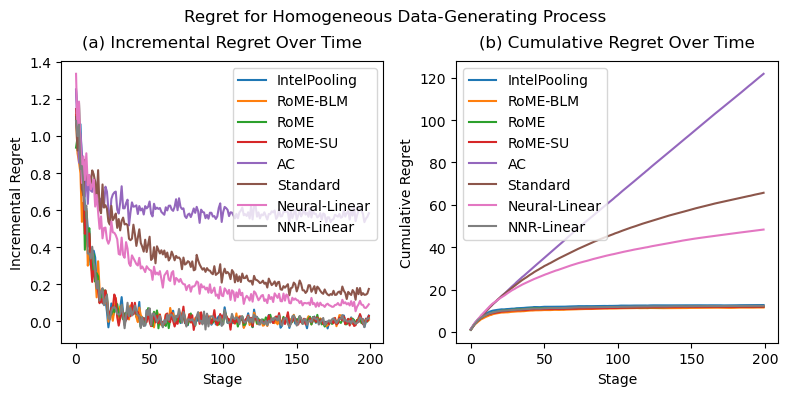

In [18]:
plot_rewards_dict(homogeneous_rewards_dict, "homogeneous")

# Simulation 2: Heterogeneous Users, Linear Baseline, No Time Effects

In [19]:
heterogeneous_rewards_dict, heterogeneous_timings_dict = run_simulation(heterogeneous_data_generator, model_files[1], n_jobs=n_jobs)

Starting parallel


2025-01-11 23:13:49.310603: I tensorflow/core/platform/cpu_feature_guard.cc:193] This TensorFlow binary is optimized with oneAPI Deep Neural Network Library (oneDNN) to use the following CPU instructions in performance-critical operations:  SSE4.1 SSE4.2 AVX AVX2 AVX512F FMA
To enable them in other operations, rebuild TensorFlow with the appropriate compiler flags.
2025-01-11 23:13:49.314082: I tensorflow/core/platform/cpu_feature_guard.cc:193] This TensorFlow binary is optimized with oneAPI Deep Neural Network Library (oneDNN) to use the following CPU instructions in performance-critical operations:  SSE4.1 SSE4.2 AVX AVX2 AVX512F FMA
To enable them in other operations, rebuild TensorFlow with the appropriate compiler flags.
2025-01-11 23:13:49.317202: I tensorflow/core/platform/cpu_feature_guard.cc:193] This TensorFlow binary is optimized with oneAPI Deep Neural Network Library (oneDNN) to use the following CPU instructions in performance-critical operations:  SSE4.1 SSE4.2 AVX AVX2 

Parallel closed


In [20]:
print_timings(heterogeneous_timings_dict)

Average elapsed time by method
IntelPooling: 42.3326036977768
RoME: 412.4668705415726
RoME-BLM: 102.49479948043823
RoME-SU: 391.41951130867005
AC: 0.11562135696411133
Standard: 0.16028094291687012
Neural-Linear: 0.7329450130462647
NNR-Linear: 31.381548805236818
Oracle: 0.019570298194885254
    IntelPooling        RoME    RoME-BLM     RoME-SU        AC  Standard  \
0      42.782652  379.062358  108.826884  378.420395  0.115995  0.160335   
1      42.501979  373.257525  108.226269  371.154066  0.114854  0.159701   
2      42.399043  384.149632  108.267228  386.628325  0.120197  0.162645   
3      43.483731  404.223924  109.430639  381.256612  0.114850  0.160637   
4      39.982852  373.493194   94.332873  370.663421  0.115644  0.160596   
5      43.409092  381.038413  112.166267  381.114873  0.117263  0.160258   
6      45.312563  380.667309  110.237957  373.727760  0.115896  0.160593   
7      42.017763  381.818065  110.554253  377.211307  0.115306  0.160687   
8      42.888281  395.012

,IntelPooling,RoME,RoME-BLM,RoME-SU,AC,Standard,Neural-Linear,NNR-Linear,Oracle
0,42.782652,379.062358,108.826884,378.420395,0.115995,0.160335,0.779470,33.645393,0.022346
1,42.501979,373.257525,108.226269,371.154066,0.114854,0.159701,0.794786,30.911914,0.019624
2,42.399043,384.149632,108.267228,386.628325,0.120197,0.162645,0.797646,32.351264,0.020262
3,43.483731,404.223924,109.430639,381.256612,0.114850,0.160637,0.726482,30.890229,0.018835
4,39.982852,373.493194,94.332873,370.663421,0.115644,0.160596,0.726712,31.352335,0.018807
5,43.409092,381.038413,112.166267,381.114873,0.117263,0.160258,0.775153,30.803115,0.019243
6,45.312563,380.667309,110.237957,373.727760,0.115896,0.160593,0.787924,31.098238,0.020729
7,42.017763,381.818065,110.554253,377.211307,0.115306,0.160687,0.798175,31.485314,0.018949
8,42.888281,395.012252,110.254857,379.344822,0.119401,0.160034,0.752548,31.082459,0.019816
9,43.848153,392.559647,110.513824,402.773425,0.119477,0.162325,0.773570,32.327008,0.020625


In [21]:
heterogeneous_rewards_filename = "checkpoints/heterogeneous_rewards.pkl"
with open(heterogeneous_rewards_filename, 'wb') as file:
    pickle.dump(heterogeneous_rewards_dict, file, protocol=pickle.HIGHEST_PROTOCOL)

In [22]:
with open(heterogeneous_rewards_filename, "rb") as file:
    heterogeneous_rewards_dict = pickle.load(file)

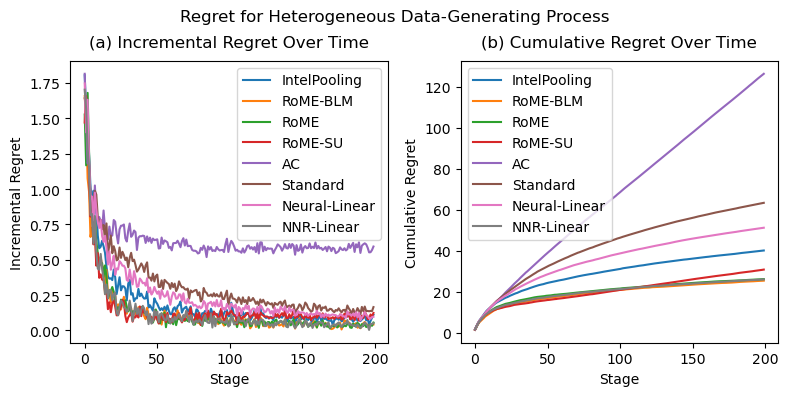

In [23]:
plot_rewards_dict(heterogeneous_rewards_dict, "heterogeneous")

# Simulation 3: Nonlinear Baseline and User-/Time-specific Effects

In [24]:
nonlinear_rewards_dict, nonlinear_timings_dict = run_simulation(nonlinear_data_generator, model_files[2], n_jobs=n_jobs)

Starting parallel


2025-01-11 23:55:05.469679: I tensorflow/core/platform/cpu_feature_guard.cc:193] This TensorFlow binary is optimized with oneAPI Deep Neural Network Library (oneDNN) to use the following CPU instructions in performance-critical operations:  SSE4.1 SSE4.2 AVX AVX2 AVX512F FMA
To enable them in other operations, rebuild TensorFlow with the appropriate compiler flags.
2025-01-11 23:55:05.858539: I tensorflow/core/platform/cpu_feature_guard.cc:193] This TensorFlow binary is optimized with oneAPI Deep Neural Network Library (oneDNN) to use the following CPU instructions in performance-critical operations:  SSE4.1 SSE4.2 AVX AVX2 AVX512F FMA
To enable them in other operations, rebuild TensorFlow with the appropriate compiler flags.
2025-01-11 23:55:05.862392: I tensorflow/core/platform/cpu_feature_guard.cc:193] This TensorFlow binary is optimized with oneAPI Deep Neural Network Library (oneDNN) to use the following CPU instructions in performance-critical operations:  SSE4.1 SSE4.2 AVX AVX2 

Parallel closed


In [25]:
print_timings(nonlinear_timings_dict)

Average elapsed time by method
IntelPooling: 45.03242547035217
RoME: 422.7765952253342
RoME-BLM: 111.06492092609406
RoME-SU: 402.65750479221344
AC: 0.261076021194458
Standard: 0.3045363140106201
Neural-Linear: 0.896413860321045
NNR-Linear: 31.689814920425416
Oracle: 0.1617891836166382
    IntelPooling        RoME    RoME-BLM     RoME-SU        AC  Standard  \
0      47.001259  387.476217  111.020468  376.551643  0.256303  0.300253   
1      44.788502  398.993287  113.000019  390.861912  0.258243  0.303145   
2      45.264603  394.951072  108.841063  380.492966  0.259954  0.305376   
3      45.003792  384.404882  111.597026  375.684171  0.257667  0.302231   
4      46.455169  398.756276  112.171593  389.076480  0.256022  0.300987   
5      45.217917  402.775603  117.633977  387.509545  0.271380  0.311792   
6      45.441931  392.200151  108.981028  377.595027  0.267253  0.309054   
7      44.639666  395.329785  113.227353  386.259068  0.346386  0.314671   
8      45.878308  394.461698  

,IntelPooling,RoME,RoME-BLM,RoME-SU,AC,Standard,Neural-Linear,NNR-Linear,Oracle
0,47.001259,387.476217,111.020468,376.551643,0.256303,0.300253,0.901335,31.135455,0.157257
1,44.788502,398.993287,113.000019,390.861912,0.258243,0.303145,0.929141,31.197402,0.159182
2,45.264603,394.951072,108.841063,380.492966,0.259954,0.305376,0.964282,32.601516,0.156777
3,45.003792,384.404882,111.597026,375.684171,0.257667,0.302231,0.913475,31.632436,0.156560
4,46.455169,398.756276,112.171593,389.076480,0.256022,0.300987,0.903196,31.436958,0.158186
5,45.217917,402.775603,117.633977,387.509545,0.271380,0.311792,0.942438,33.501428,0.166235
6,45.441931,392.200151,108.981028,377.595027,0.267253,0.309054,0.959903,32.724093,0.161603
7,44.639666,395.329785,113.227353,386.259068,0.346386,0.314671,0.916898,30.734623,0.155892
8,45.878308,394.461698,109.988501,378.524104,0.259014,0.302771,0.893327,30.819657,0.158928
9,46.222550,379.796955,111.287507,376.667193,0.254472,0.299549,0.909012,31.222827,0.153988


In [26]:
nonlinear_rewards_filename = "checkpoints/nonlinear_rewards.pkl"
with open(nonlinear_rewards_filename, 'wb') as file:
    pickle.dump(nonlinear_rewards_dict, file, protocol=pickle.HIGHEST_PROTOCOL)

In [27]:
with open(nonlinear_rewards_filename, "rb") as file:
    nonlinear_rewards_dict = pickle.load(file)

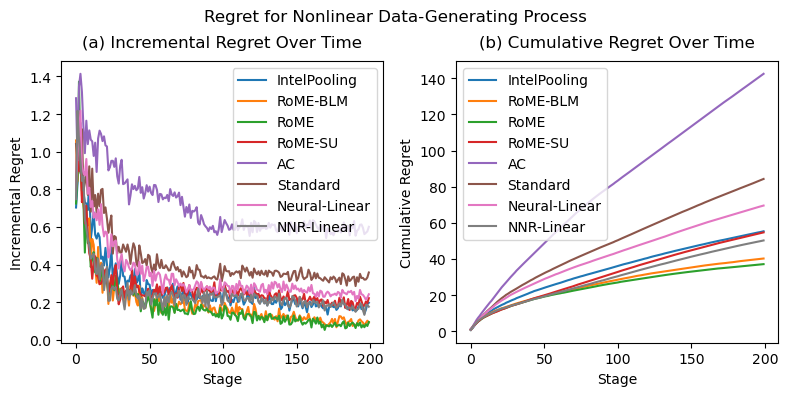

In [28]:
plot_rewards_dict(nonlinear_rewards_dict, "nonlinear")

# Cumulative Regret for All Three Settings

## Calculations

In [29]:
# Calculate incremental regret
incremental_homogeneous_regret_dict = {
    method_name: get_avg_stage_reward(homogeneous_rewards_dict["Oracle"]) - get_avg_stage_reward(homogeneous_rewards_dict[method_name])
    for method_name in non_oracle_method_names}
incremental_heterogeneous_regret_dict = {
    method_name: get_avg_stage_reward(heterogeneous_rewards_dict["Oracle"]) - get_avg_stage_reward(heterogeneous_rewards_dict[method_name])
    for method_name in non_oracle_method_names}
incremental_nonlinear_regret_dict = {
    method_name: get_avg_stage_reward(nonlinear_rewards_dict["Oracle"]) - get_avg_stage_reward(nonlinear_rewards_dict[method_name])
    for method_name in non_oracle_method_names}

# Calculate cumulative regret
cumulative_homogeneous_regret_dict = {method_name: np.cumsum(incremental_homogeneous_regret_dict[method_name], axis=0) for method_name in non_oracle_method_names}
cumulative_heterogeneous_regret_dict = {method_name: np.cumsum(incremental_heterogeneous_regret_dict[method_name], axis=0) for method_name in non_oracle_method_names}
cumulative_nonlinear_regret_dict = {method_name: np.cumsum(incremental_nonlinear_regret_dict[method_name], axis=0) for method_name in non_oracle_method_names}

# Final regret
final_homogeneous_regret_df = pd.DataFrame({
    method_name: cumulative_homogeneous_regret_dict[method_name][-1]
    for method_name in non_oracle_method_names})
final_homogeneous_regret_df.to_csv("./checkpoints/final_homogeneous_regret.csv", index=False)

final_heterogeneous_regret_df = pd.DataFrame({
    method_name: cumulative_heterogeneous_regret_dict[method_name][-1]
    for method_name in non_oracle_method_names})
final_heterogeneous_regret_df.to_csv("./checkpoints/final_heterogeneous_regret.csv", index=False)

final_nonlinear_regret_df = pd.DataFrame({
    method_name: cumulative_nonlinear_regret_dict[method_name][-1]
    for method_name in non_oracle_method_names})
final_nonlinear_regret_df.to_csv("./checkpoints/final_nonlinear_regret.csv", index=False)

## Plots

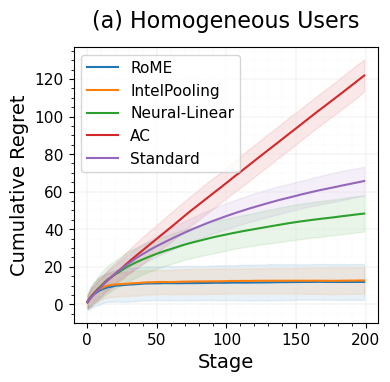

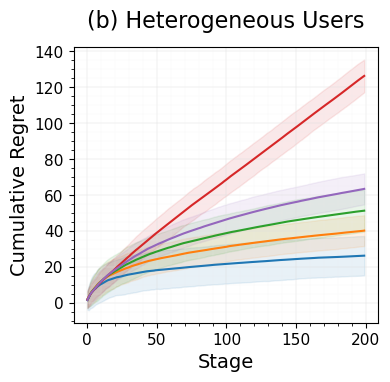

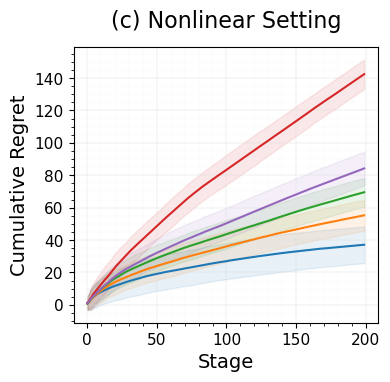

In [30]:
def plot_cumulative_regret(cumulative_regret_dict, setting_name, include_legend=False, loc="main", include_bands=True):
    fig, ax = plt.subplots(1, 1, figsize=(4,4))
    for i, method_name in enumerate(cumulative_regret_dict.keys()):
        color_i = f"C{i}"
        method_means = cumulative_regret_dict[method_name].mean(axis=1)
        method_range = np.arange(method_means.size)
        method_sds = cumulative_regret_dict[method_name].std(axis=1)
        method_lower = method_means - 1.96 * method_sds
        method_upper = method_means + 1.96 * method_sds
        if include_bands:
            ax.fill_between(method_range, method_lower, method_upper, color=color_i, alpha=0.1)
        ax.plot(method_range, method_means, label=method_name, color=color_i)
        
    ax.grid(which='major', color='#DDDDDD', linewidth=0.3)
    ax.grid(which='minor', color='#EEEEEE', linestyle=':', linewidth=0.3)
    ax.minorticks_on()
    ax.set_title(setting_name, pad=14, fontsize=16)
    ax.set_ylabel("Cumulative Regret", fontsize=14)
    ax.set_xlabel("Stage", fontsize=14)
    ax.tick_params(axis='both', labelsize=11)
    if include_legend:
        ax.legend(fontsize=11)

    plt.tight_layout()
    plt.subplots_adjust(top=0.85)
    setting_name_for_file = setting_name.replace("(", "").replace(")", "").replace(" ", "-")
    fig.savefig(f"figures/cumulative-regret-{setting_name_for_file}-{loc}.png")
    fig.savefig(f"figures/cumulative-regret-{setting_name_for_file}-{loc}.pdf")
    # fig.suptitle("Comparison of Cumulative Regret by Method")
    plt.show()

main_paper_methods = ["RoME", "IntelPooling", "Neural-Linear", "AC", "Standard"]

plot_cumulative_regret(
    {m:cumulative_homogeneous_regret_dict[m] for m in main_paper_methods},
    setting_name="(a) Homogeneous Users", include_legend=True)

plot_cumulative_regret(
    {m:cumulative_heterogeneous_regret_dict[m] for m in main_paper_methods},
    setting_name="(b) Heterogeneous Users", include_legend=False)

plot_cumulative_regret(
    {m:cumulative_nonlinear_regret_dict[m] for m in main_paper_methods},
    setting_name="(c) Nonlinear Setting", include_legend=False)

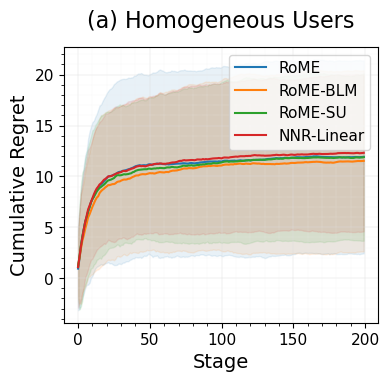

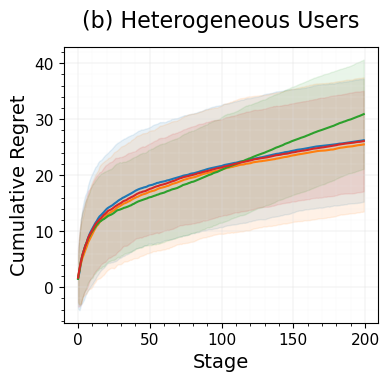

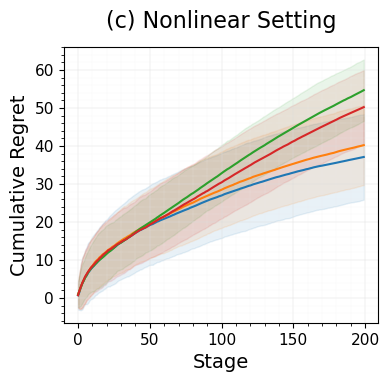

In [31]:
appendix_methods = ["RoME", "RoME-BLM", "RoME-SU", "NNR-Linear"]

plot_cumulative_regret(
    {m:cumulative_homogeneous_regret_dict[m] for m in appendix_methods},
    setting_name="(a) Homogeneous Users", include_legend=True, loc="app")

plot_cumulative_regret(
    {m:cumulative_heterogeneous_regret_dict[m] for m in appendix_methods},
    setting_name="(b) Heterogeneous Users", include_legend=False, loc="app")

plot_cumulative_regret(
    {m:cumulative_nonlinear_regret_dict[m] for m in appendix_methods},
    setting_name="(c) Nonlinear Setting", include_legend=False, loc="app")

## Comparison Tables

### Extra

In [32]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [33]:
final_homogeneous_regret_df = pd.read_csv("./checkpoints/final_homogeneous_regret.csv")
final_heterogeneous_regret_df = pd.read_csv("./checkpoints/final_heterogeneous_regret.csv")
final_nonlinear_regret_df = pd.read_csv("./checkpoints/final_nonlinear_regret.csv")

In [34]:
non_oracle_method_names_sorted = [
    'RoME',
    'RoME-BLM',
    'RoME-SU',
    'NNR-Linear',
    'IntelPooling',
    'Neural-Linear',
    'Standard',
    'AC',
]

In [35]:
def create_comparison_df(final_regret_df):
    comparison_outer_list = []
    win_percentages = []
    for method_row in non_oracle_method_names_sorted:
        comparison_inner_list = []
        win_percentage = 0.
        for method_column in non_oracle_method_names_sorted:
            diffs = final_regret_df[method_column] - final_regret_df[method_row]
            percent_row_better = np.mean(diffs > 0)
            avg_diff = np.mean(diffs)
            p_value = ttest_1samp(diffs, popmean=0).pvalue
            if method_row == method_column:
                cell_text = "-"
            else:
                win_percentage += percent_row_better / (len(non_oracle_method_names_sorted) - 1)
                cell_text = f"{percent_row_better:.0%}{'*' if p_value < 0.05 else ''}"
            comparison_inner_list.append(cell_text)
        comparison_outer_list.append(comparison_inner_list)
        win_percentages.append(f"{win_percentage:.0%}")
    comparison_df = pd.DataFrame(
        comparison_outer_list,
        index=[f"{i+1}. {n}" for i, n in enumerate(non_oracle_method_names_sorted)],
        columns=range(1, len(non_oracle_method_names_sorted)+1))
    comparison_df["\textbf{Avg}"] = win_percentages
    latex_table = comparison_df.to_latex(escape=False).replace("%", "\%")
    print(latex_table)
    return comparison_df

In [36]:
homogeneous_comparison_df = create_comparison_df(final_homogeneous_regret_df)
homogeneous_comparison_df

\begin{tabular}{llllllllll}
\toprule
 & 1 & 2 & 3 & 4 & 5 & 6 & 7 & 8 & 	extbf{Avg} \\
\midrule
1. RoME & - & 46\% & 52\% & 58\% & 60\% & 100\%* & 100\%* & 100\%* & 74\% \\
2. RoME-BLM & 54\% & - & 60\% & 50\% & 60\% & 100\%* & 100\%* & 100\%* & 75\% \\
3. RoME-SU & 48\% & 40\% & - & 46\% & 54\% & 100\%* & 100\%* & 100\%* & 70\% \\
4. NNR-Linear & 42\% & 50\% & 54\% & - & 56\% & 100\%* & 100\%* & 100\%* & 72\% \\
5. IntelPooling & 40\% & 40\% & 46\% & 44\% & - & 100\%* & 100\%* & 100\%* & 67\% \\
6. Neural-Linear & 0\%* & 0\%* & 0\%* & 0\%* & 0\%* & - & 100\%* & 100\%* & 29\% \\
7. Standard & 0\%* & 0\%* & 0\%* & 0\%* & 0\%* & 0\%* & - & 100\%* & 14\% \\
8. AC & 0\%* & 0\%* & 0\%* & 0\%* & 0\%* & 0\%* & 0\%* & - & 0\% \\
\bottomrule
\end{tabular}



,1,2,3,4,5,6,7,8,\textbf{Avg}
1. RoME,-,46%,52%,58%,60%,100%*,100%*,100%*,74%
2. RoME-BLM,54%,-,60%,50%,60%,100%*,100%*,100%*,75%
3. RoME-SU,48%,40%,-,46%,54%,100%*,100%*,100%*,70%
4. NNR-Linear,42%,50%,54%,-,56%,100%*,100%*,100%*,72%
5. IntelPooling,40%,40%,46%,44%,-,100%*,100%*,100%*,67%
6. Neural-Linear,0%*,0%*,0%*,0%*,0%*,-,100%*,100%*,29%
7. Standard,0%*,0%*,0%*,0%*,0%*,0%*,-,100%*,14%
8. AC,0%*,0%*,0%*,0%*,0%*,0%*,0%*,-,0%


In [37]:
heterogeneous_comparison_df = create_comparison_df(final_heterogeneous_regret_df)
heterogeneous_comparison_df

\begin{tabular}{llllllllll}
\toprule
 & 1 & 2 & 3 & 4 & 5 & 6 & 7 & 8 & 	extbf{Avg} \\
\midrule
1. RoME & - & 54\% & 76\%* & 54\% & 100\%* & 100\%* & 100\%* & 100\%* & 83\% \\
2. RoME-BLM & 46\% & - & 80\%* & 46\% & 96\%* & 100\%* & 100\%* & 100\%* & 81\% \\
3. RoME-SU & 24\%* & 20\%* & - & 16\%* & 94\%* & 100\%* & 100\%* & 100\%* & 65\% \\
4. NNR-Linear & 46\% & 54\% & 84\%* & - & 100\%* & 100\%* & 100\%* & 100\%* & 83\% \\
5. IntelPooling & 0\%* & 4\%* & 6\%* & 0\%* & - & 96\%* & 100\%* & 100\%* & 44\% \\
6. Neural-Linear & 0\%* & 0\%* & 0\%* & 0\%* & 4\%* & - & 96\%* & 100\%* & 29\% \\
7. Standard & 0\%* & 0\%* & 0\%* & 0\%* & 0\%* & 4\%* & - & 100\%* & 15\% \\
8. AC & 0\%* & 0\%* & 0\%* & 0\%* & 0\%* & 0\%* & 0\%* & - & 0\% \\
\bottomrule
\end{tabular}



,1,2,3,4,5,6,7,8,\textbf{Avg}
1. RoME,-,54%,76%*,54%,100%*,100%*,100%*,100%*,83%
2. RoME-BLM,46%,-,80%*,46%,96%*,100%*,100%*,100%*,81%
3. RoME-SU,24%*,20%*,-,16%*,94%*,100%*,100%*,100%*,65%
4. NNR-Linear,46%,54%,84%*,-,100%*,100%*,100%*,100%*,83%
5. IntelPooling,0%*,4%*,6%*,0%*,-,96%*,100%*,100%*,44%
6. Neural-Linear,0%*,0%*,0%*,0%*,4%*,-,96%*,100%*,29%
7. Standard,0%*,0%*,0%*,0%*,0%*,4%*,-,100%*,15%
8. AC,0%*,0%*,0%*,0%*,0%*,0%*,0%*,-,0%


### Nonlinear Setting

In [38]:
nonlinear_comparison_df = create_comparison_df(final_nonlinear_regret_df)
nonlinear_comparison_df

\begin{tabular}{llllllllll}
\toprule
 & 1 & 2 & 3 & 4 & 5 & 6 & 7 & 8 & 	extbf{Avg} \\
\midrule
1. RoME & - & 64\%* & 100\%* & 100\%* & 100\%* & 100\%* & 100\%* & 100\%* & 95\% \\
2. RoME-BLM & 36\%* & - & 98\%* & 98\%* & 100\%* & 100\%* & 100\%* & 100\%* & 90\% \\
3. RoME-SU & 0\%* & 2\%* & - & 24\%* & 50\% & 100\%* & 100\%* & 100\%* & 54\% \\
4. NNR-Linear & 0\%* & 2\%* & 76\%* & - & 80\%* & 100\%* & 100\%* & 100\%* & 65\% \\
5. IntelPooling & 0\%* & 0\%* & 50\% & 20\%* & - & 98\%* & 100\%* & 100\%* & 53\% \\
6. Neural-Linear & 0\%* & 0\%* & 0\%* & 0\%* & 2\%* & - & 100\%* & 100\%* & 29\% \\
7. Standard & 0\%* & 0\%* & 0\%* & 0\%* & 0\%* & 0\%* & - & 100\%* & 14\% \\
8. AC & 0\%* & 0\%* & 0\%* & 0\%* & 0\%* & 0\%* & 0\%* & - & 0\% \\
\bottomrule
\end{tabular}



,1,2,3,4,5,6,7,8,\textbf{Avg}
1. RoME,-,64%*,100%*,100%*,100%*,100%*,100%*,100%*,95%
2. RoME-BLM,36%*,-,98%*,98%*,100%*,100%*,100%*,100%*,90%
3. RoME-SU,0%*,2%*,-,24%*,50%,100%*,100%*,100%*,54%
4. NNR-Linear,0%*,2%*,76%*,-,80%*,100%*,100%*,100%*,65%
5. IntelPooling,0%*,0%*,50%,20%*,-,98%*,100%*,100%*,53%
6. Neural-Linear,0%*,0%*,0%*,0%*,2%*,-,100%*,100%*,29%
7. Standard,0%*,0%*,0%*,0%*,0%*,0%*,-,100%*,14%
8. AC,0%*,0%*,0%*,0%*,0%*,0%*,0%*,-,0%


In [39]:
final_nonlinear_regret_df

,IntelPooling,RoME-BLM,RoME,RoME-SU,AC,Standard,Neural-Linear,NNR-Linear
0,56.606457,46.060847,45.698595,57.928217,140.323086,86.726939,77.016183,58.682309
1,54.657812,42.987087,47.186198,55.492035,142.993894,85.531240,68.634330,54.846909
2,54.175764,39.084022,43.379833,55.097454,144.290930,90.062020,72.766946,51.475858
3,53.049202,48.010443,39.368045,58.806183,143.600715,91.508396,71.332423,49.042334
4,58.308240,38.132810,39.034203,57.360769,138.892765,79.608093,71.205024,42.354018
5,53.917782,40.789235,33.055274,58.102061,141.242613,76.020290,75.039528,52.300352
6,57.154922,36.056799,39.305563,55.844380,144.193903,82.825754,66.999995,49.464576
7,48.360189,41.287614,43.856155,54.958775,140.001034,88.965998,66.653647,55.854917
8,58.378961,30.068270,46.368367,49.748263,142.727129,82.897273,70.604489,50.359945
9,51.517954,36.732126,40.645245,50.872044,136.610537,81.393758,66.646975,47.505876


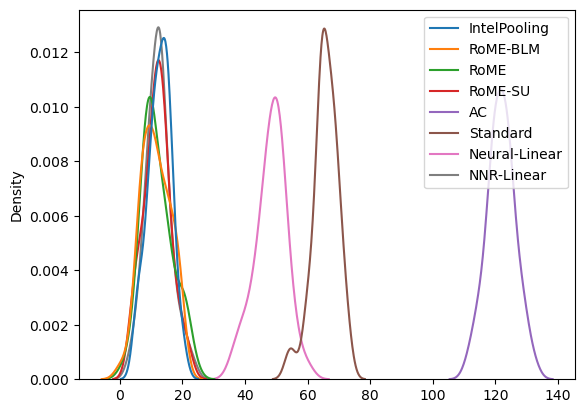

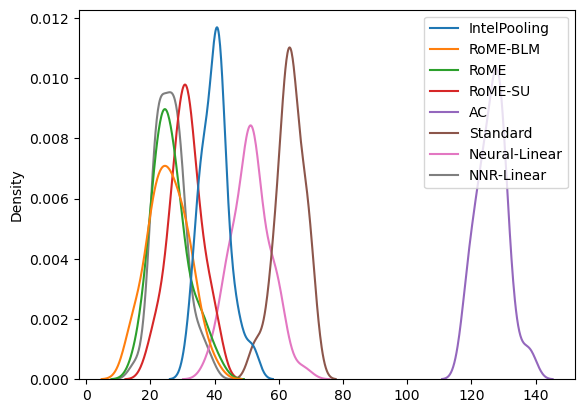

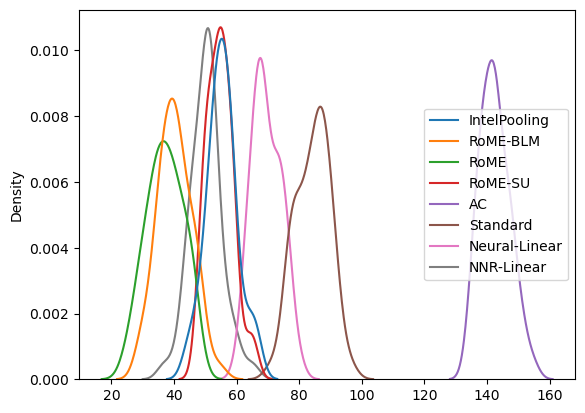

In [40]:
sns.kdeplot(data=final_homogeneous_regret_df)
plt.show()

sns.kdeplot(data=final_heterogeneous_regret_df)
plt.show()

sns.kdeplot(data=final_nonlinear_regret_df)
plt.show()